In [1]:
import pandas as pd
import matplotlib.pyplot as plt

customers = pd.read_csv('data/customers.csv')
policies  = pd.read_csv('data/policies.csv')
claims    = pd.read_csv('data/claims.csv')

# Basic structure
print(customers.shape)       # (300, 6)
print(customers.dtypes)
print(customers.describe())

# Missing values
print(customers.isnull().sum())
print(policies.isnull().sum())
print(claims.isnull().sum())
# approved_amount has ~121 nulls — expected, as pending/rejected claims have no approved amount

(300, 6)
customer_id        object
name               object
age                 int64
region             object
years_licensed      int64
risk_score        float64
dtype: object
              age  years_licensed  risk_score
count  300.000000      300.000000  300.000000
mean    43.320000       21.730000    5.351333
std     15.326686       12.490683    2.577877
min     18.000000        1.000000    1.000000
25%     30.000000       11.000000    3.075000
50%     43.500000       22.000000    5.200000
75%     56.000000       32.000000    7.600000
max     69.000000       44.000000   10.000000
customer_id       0
name              0
age               0
region            0
years_licensed    0
risk_score        0
dtype: int64
policy_id         0
customer_id       0
product_type      0
start_date        0
end_date          0
annual_premium    0
status            0
dtype: int64
claim_id             0
policy_id            0
claim_date           0
claim_type           0
claimed_amount       0
approv

In [8]:
# Fix nulls in approved_amount — fill with 0 (no payout)
claims['approved_amount'] = claims['approved_amount'].fillna(0)

# Aggregate to customer level
claim_features = (
    policies
    .merge(claims, on='policy_id', how='left')
    .groupby('customer_id')
    .agg(
        total_policies=('policy_id',       'nunique'),
        total_claimed =('claimed_amount',  'sum'),
        total_approved=('approved_amount', 'sum'),
        n_claims      =('claim_id',        'count'),
        avg_premium   =('annual_premium',  'mean')
    )
    .reset_index()
)

# Merge with customer info
df = customers.merge(claim_features, on='customer_id', how='left')

# Target variable: 1 if customer has made at least one claim
df['has_claim'] = (df['n_claims'] > 0).astype(int)

print(df['has_claim'].value_counts())
# 1 → 166,  0 → 134

has_claim
1    166
0    134
Name: count, dtype: int64


In [9]:
# Encode categorical: region → dummy variables
df = pd.get_dummies(df, columns=['region'])

# Drop columns that would cause data leakage or are not useful as features
# n_claims / total_claimed / total_approved directly encode the target → leakage!
drop_cols = ['customer_id', 'name', 'has_claim', 'n_claims', 'total_claimed', 'total_approved']

X = df.drop(columns=drop_cols)
y = df['has_claim']

print(X.shape)  # (300, 10)
print(X.columns.tolist())

(300, 10)
['age', 'years_licensed', 'risk_score', 'total_policies', 'avg_premium', 'region_Auckland', 'region_Christchurch', 'region_Hamilton', 'region_Tauranga', 'region_Wellington']


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)  # (240, 10)
print(X_test.shape)   # (60, 10)

(240, 10)
(60, 10)


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")   # 0.600
print(f"AUC:      {roc_auc_score(y_test, y_prob_rf):.3f}")    # 0.583
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.600
AUC:      0.583
              precision    recall  f1-score   support

           0       0.64      0.47      0.54        30
           1       0.58      0.73      0.65        30

    accuracy                           0.60        60
   macro avg       0.61      0.60      0.59        60
weighted avg       0.61      0.60      0.59        60

[[14 16]
 [ 8 22]]


In [12]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")  # 0.533
print(f"AUC:      {roc_auc_score(y_test, y_prob_xgb):.3f}")   # 0.508
print(confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.533
AUC:      0.508
[[13 17]
 [11 19]]


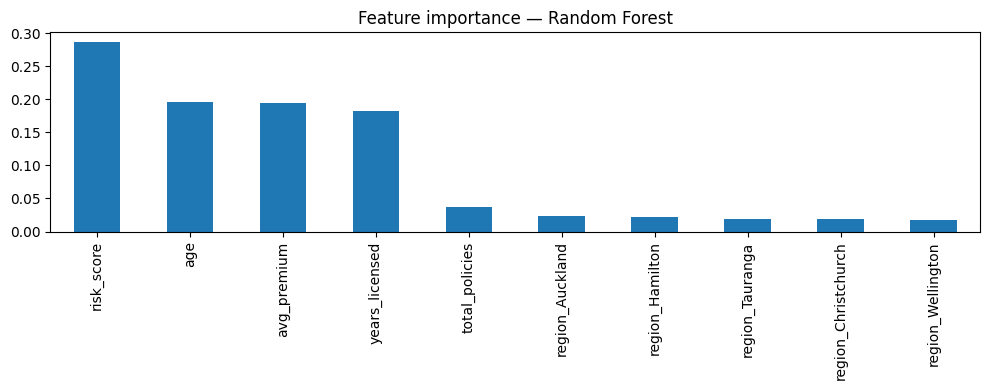

risk_score             0.287082
age                    0.195356
avg_premium            0.194826
years_licensed         0.182729
total_policies         0.037525
region_Auckland        0.023950
region_Hamilton        0.022515
region_Tauranga        0.019702
region_Christchurch    0.018204
region_Wellington      0.018110
dtype: float64


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10, 4))
plt.title('Feature importance — Random Forest')
plt.tight_layout()
plt.show()

print(feat_imp)